In [24]:
import os
import json
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import models

from PIL import Image
from tqdm import tqdm

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import f1_score

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [26]:
TRAIN_IMG = "/kaggle/input/datasets/shivvvm/filtered-dataset-v1/filtered_dataset/train/image"
TRAIN_ANNO = "/kaggle/input/datasets/shivvvm/filtered-dataset-v1/filtered_dataset/train/annos"

VAL_IMG = "/kaggle/input/datasets/shivvvm/filtered-dataset-v1/filtered_dataset/validation/image"
VAL_ANNO = "/kaggle/input/datasets/shivvvm/filtered-dataset-v1/filtered_dataset/validation/annos"

NUM_CLASSES = 5

In [27]:
train_transform = A.Compose([
    A.Resize(256,256),
    A.RandomCrop(224,224),

    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=20,p=0.5),

    A.RandomBrightnessContrast(p=0.4),
    A.ColorJitter(p=0.4),

    A.Normalize(),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(224,224),
    A.Normalize(),
    ToTensorV2()
])

In [28]:
category_map = {1:0, 2:1, 7:2, 8:3, 9:4}

def get_labels(json_path):

    with open(json_path) as f:
        data = json.load(f)

    label = np.zeros(NUM_CLASSES)

    for k in data:
        if "item" in k:

            cat = data[k]["category_id"]

            if cat in category_map:
                label[category_map[cat]] = 1

    return label

In [29]:
class FashionDataset(Dataset):

    def __init__(self, img_dir, anno_dir, image_list, transform):

        self.img_dir = img_dir
        self.anno_dir = anno_dir
        self.images = image_list
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img_name = self.images[idx]

        img_path = os.path.join(self.img_dir, img_name)
        anno_path = os.path.join(self.anno_dir, img_name.replace(".jpg",".json"))

        image = np.array(Image.open(img_path).convert("RGB"))

        label = get_labels(anno_path)

        image = self.transform(image=image)["image"]

        return image, torch.tensor(label).float()

In [30]:
train_images = sorted(os.listdir(TRAIN_IMG))[:30000]
val_images = sorted(os.listdir(VAL_IMG))[:5000]

print(len(train_images), len(val_images))

30000 5000


In [8]:
from collections import defaultdict

counts = defaultdict(int)

for img_name in train_images:

    anno_path = os.path.join(TRAIN_ANNO, img_name.replace(".jpg",".json"))

    with open(anno_path) as f:
        data = json.load(f)

    for item in data.values():
        counts[item["category_id"]] += 1

print("Distribution in first 30000 images:\n")

for k,v in sorted(counts.items()):
    print(f"Category {k}: {v}")

Distribution in first 30000 images:

Category 1: 14796
Category 2: 7435
Category 7: 7648
Category 8: 11710
Category 9: 6163


In [31]:
train_dataset = FashionDataset(
    TRAIN_IMG,
    TRAIN_ANNO,
    train_images,
    train_transform
)

val_dataset = FashionDataset(
    VAL_IMG,
    VAL_ANNO,
    val_images,
    val_transform
)

In [32]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

In [11]:
model = models.resnet50(weights="IMAGENET1K_V1")

in_features = model.fc.in_features

model.fc = nn.Linear(in_features, NUM_CLASSES)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 190MB/s] 


In [12]:

# categories present in filtered dataset
class_ids = [1,2,7,8,9]

class_counts = np.array([counts[c] for c in class_ids])

total_images = 30000

pos_weight = (total_images - class_counts) / class_counts

pos_weight = torch.tensor(pos_weight, dtype=torch.float32).to(device)

print("class_counts:", class_counts)
print("pos_weight:", pos_weight)

class_counts: [14796  7435  7648 11710  6163]
pos_weight: tensor([1.0276, 3.0350, 2.9226, 1.5619, 3.8678], device='cuda:0')


In [13]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.AdamW(model.parameters(),lr=3e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=10
)



In [14]:
def evaluate(model):

    model.eval()

    preds = []
    targets = []

    with torch.no_grad():

        for imgs,labels in val_loader:

            imgs = imgs.to(device)
            labels = labels.to(device)

            out = model(imgs)

            prob = torch.sigmoid(out)

            pred = (prob > 0.5).float()

            preds.append(pred.cpu().numpy())
            targets.append(labels.cpu().numpy())

    preds = np.concatenate(preds)
    targets = np.concatenate(targets)

    f1 = f1_score(targets,preds,average="macro")

    return f1

In [15]:
EPOCHS = 20
best_f1 = 0

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0

    for imgs,labels in tqdm(train_loader):

        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        out = model(imgs)

        loss = criterion(out,labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    scheduler.step()

    val_f1 = evaluate(model)

    print("Epoch:",epoch)
    print("Loss:",running_loss/len(train_loader))
    print("Val F1:",val_f1)

    if val_f1 > best_f1:

        best_f1 = val_f1

        torch.save(model.state_dict(),"resnet50_transfer_best.pth")

        print("Saved best model")

100%|██████████| 938/938 [05:18<00:00,  2.94it/s]


Epoch: 0
Loss: 0.6629341917315017
Val F1: 0.6345519439586103
Saved best model


100%|██████████| 938/938 [05:28<00:00,  2.85it/s]


Epoch: 1
Loss: 0.5567882025419776
Val F1: 0.6915262323322189
Saved best model


100%|██████████| 938/938 [05:27<00:00,  2.86it/s]


...

Epoch: 17
Loss: 0.30326625692850745
Val F1: 0.7002372626039538


100%|██████████| 938/938 [05:26<00:00,  2.88it/s]


Epoch: 18
Loss: 0.3170266059447707
Val F1: 0.7216346488659999


100%|██████████| 938/938 [05:25<00:00,  2.88it/s]


Epoch: 19
Loss: 0.32440294079117177
Val F1: 0.7157351816800613


In [16]:
print("Best Validation F1:",best_f1)

Best Validation F1: 0.7585680463333253


In [17]:
model = models.resnet50(weights=None)

in_features = model.fc.in_features

model.fc = nn.Linear(in_features, NUM_CLASSES)

model = model.to(device)

In [18]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

In [19]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

In [20]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)

In [21]:
EPOCHS = 20
best_f1 = 0

for epoch in range(EPOCHS):

    model.train()
    running_loss = 0

    for imgs, labels in tqdm(train_loader):

        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(imgs)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    scheduler.step()

    val_f1 = evaluate(model)

    print("Epoch:", epoch)
    print("Loss:", running_loss / len(train_loader))
    print("Val F1:", val_f1)

    if val_f1 > best_f1:

        best_f1 = val_f1

        torch.save(model.state_dict(), "resnet50_scratch_best.pth")

        print("Saved best scratch model")

100%|██████████| 938/938 [05:31<00:00,  2.83it/s]


Epoch: 0
Loss: 0.9601216164987478
Val F1: 0.2570380695731639
Saved best scratch model


100%|██████████| 938/938 [05:30<00:00,  2.84it/s]


Epoch: 1
Loss: 0.9431041083229121
Val F1: 0.3906245890127245
Saved best scratch model


100%|██████████| 938/938 [05:29<00:00,  2.84it/s]


...

Epoch: 17
Loss: 0.6761379748392207
Val F1: 0.576591355417458
Saved best scratch model


100%|██████████| 938/938 [05:31<00:00,  2.83it/s]


Epoch: 18
Loss: 0.6688783755942956
Val F1: 0.5778532747341762
Saved best scratch model


100%|██████████| 938/938 [05:30<00:00,  2.84it/s]


Epoch: 19
Loss: 0.6635790169556767
Val F1: 0.5803954455311824
Saved best scratch model


In [ ]:
# import torch
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from sklearn.metrics import precision_recall_fscore_support, roc_curve, auc, classification_report
# from torch.utils.data import DataLoader

# def evaluate_model(model, test_loader, device, class_names):
#     model.eval()
#     all_labels = []
#     all_probs = []

#     with torch.no_grad():
#         for inputs, labels in test_loader:
#             inputs = inputs.to(device)
#             outputs = model(inputs)
#             # Use sigmoid for multi-label probabilities as per report 
#             probs = torch.sigmoid(outputs).cpu().numpy()
#             all_probs.append(probs)
#             all_labels.append(labels.numpy())

#     all_labels = np.vstack(all_labels)
#     all_probs = np.vstack(all_probs)
#     # Thresholding at 0.5 for binary predictions
#     all_preds = (all_probs > 0.5).astype(int)

#     # 1. Classification Performance Summary (Averaged Metrics) 
#     micro_p, micro_r, micro_f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='micro')
#     macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro')
    
#     summary_df = pd.DataFrame({
#         'Metric': ['Micro', 'Macro'],
#         'Precision': [micro_p, macro_p],
#         'Recall': [micro_r, macro_r],
#         'F1-Score': [micro_f1, macro_f1]
#     })
    
#     # 2. Per Class Metrics Table 
#     report_dict = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
#     per_class_df = pd.DataFrame(report_dict).transpose().iloc[:len(class_names)]

#     # 3. ROC and AUC Curves 
#     plt.figure(figsize=(10, 8))
    
#     # Compute ROC curve and ROC area for each class
#     fpr = dict()
#     tpr = dict()
#     roc_auc = dict()
#     for i in range(len(class_names)):
#         fpr[i], tpr[i], _ = roc_curve(all_labels[:, i], all_probs[:, i])
#         roc_auc[i] = auc(fpr[i], tpr[i])
#         plt.plot(fpr[i], tpr[i], label=f'{class_names[i]} (AUC = {roc_auc[i]:.4f})')

#     # Compute micro-average ROC curve and ROC area
#     fpr["micro"], tpr["micro"], _ = roc_curve(all_labels.ravel(), all_probs.ravel())
#     roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    
#     plt.plot(fpr["micro"], tpr["micro"], label=f'Micro-average (AUC = {roc_auc["micro"]:.4f})',
#              color='deeppink', linestyle=':', linewidth=4)

#     plt.plot([0, 1], [0, 1], 'k--')
#     plt.xlim([0.0, 1.0])
#     plt.ylim([0.0, 1.05])
#     plt.xlabel('False Positive Rate (Fall-Out)')
#     plt.ylabel('True Positive Rate (Recall)')
#     plt.title('Receiver Operating Characteristic (ROC) Curve')
#     plt.legend(loc="lower right")
#     plt.grid(alpha=0.3)
#     plt.show()

#     return summary_df, per_class_df

# # # Example Usage:
# # model.load_state_dict(torch.load('/kaggle/input/datasets/shivvvm/evaluation-dataset/resnet50_best_scratch.pth'))
# # class_list = ['short sleeve top', 'long sleeve top', 'trousers', 'shorts', 'skirt']
# # summary, details = evaluate_model(model, val_loader, device, class_list)
# # print(summary)
# # print(details)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


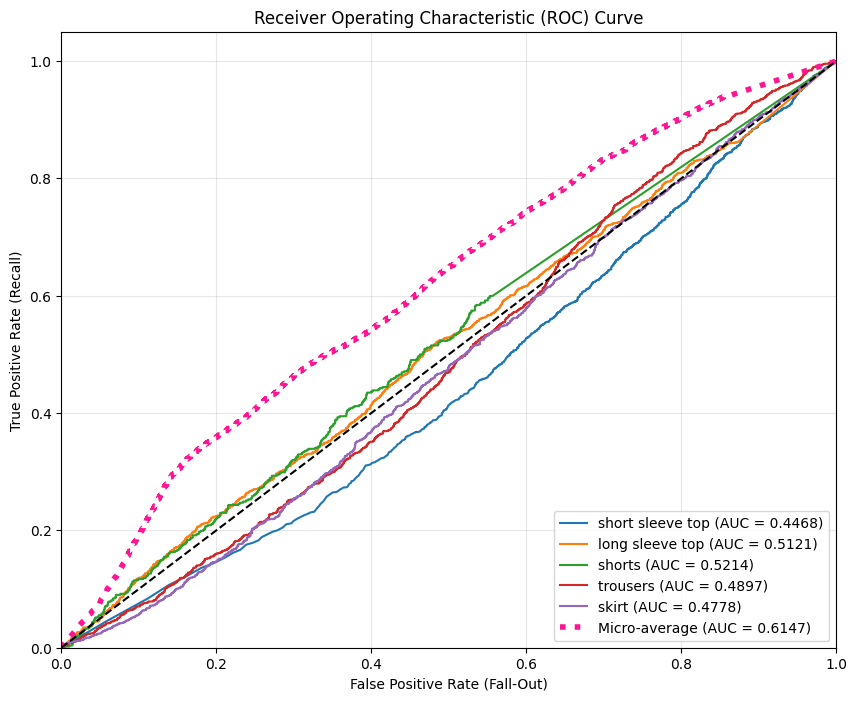

  Metric  Precision    Recall  F1-Score
0  Micro   0.410381  0.368436  0.388279
1  Macro   0.271855  0.248648  0.175052
                  precision    recall  f1-score  support
short sleeve top   0.460286  0.995217  0.629451   2300.0
long sleeve top    0.333333  0.000720  0.001438   1388.0
shorts             0.000000  0.000000  0.000000    522.0
trousers           0.232323  0.244124  0.238078   1319.0
skirt              0.333333  0.003177  0.006293   1574.0


In [ ]:
# # 1. Set the device
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # 2. Define the architecture (the "skeleton")
# # Make sure the num_classes matches what you used during training (looks like 5)
# model = models.resnet50(weights=None) 
# num_ftrs = model.fc.in_features
# model.fc = nn.Linear(num_ftrs, 5) # Adjust '5' if your class_list length is different

# # 3. Move model to device
# model = model.to(device)

# # 4. Now you can load the weights
# model.load_state_dict(torch.load('/kaggle/input/datasets/shivvvm/evaluation-dataset/resnet50_best_scratch.pth', map_location=device))

# # 5. Run your evaluation
# class_list = [
#     "short sleeve top", # Index 0
#     "long sleeve top",  # Index 1
#     "shorts",           # Index 2
#     "trousers",         # Index 3
#     "skirt"             # Index 4
# ]
# summary, details = evaluate_model(model, val_loader, device, class_list)
# print(summary)
# print(details)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


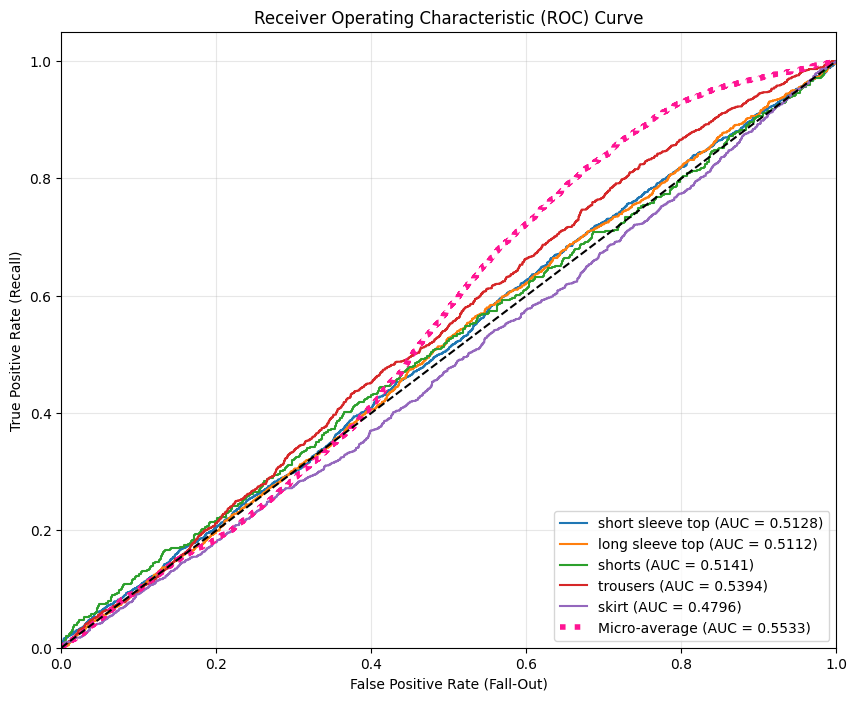

  Metric  Precision    Recall  F1-Score
0  Micro   0.267563  0.212868  0.237102
1  Macro   0.508874  0.227504  0.122190
                  precision    recall  f1-score  support
short sleeve top   1.000000  0.001739  0.003472   2300.0
long sleeve top    0.279202  0.141210  0.187560   1388.0
shorts             0.000000  0.000000  0.000000    522.0
trousers           0.265170  0.993935  0.418649   1319.0
skirt              1.000000  0.000635  0.001270   1574.0


In [ ]:
# # 1. Set the device
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # 2. Define the architecture (the "skeleton")
# # Make sure the num_classes matches what you used during training (looks like 5)
# model = models.resnet50(weights=None) 
# num_ftrs = model.fc.in_features
# model.fc = nn.Linear(num_ftrs, 5) # Adjust '5' if your class_list length is different

# # 3. Move model to device
# model = model.to(device)

# # 4. Now you can load the weights
# model.load_state_dict(torch.load('/kaggle/input/datasets/shivvvm/evaluation-dataset/resnet50_transfer_best.pth', map_location=device))

# # 5. Run your evaluation
# class_list = [
#     "short sleeve top", # Index 0
#     "long sleeve top",  # Index 1
#     "shorts",           # Index 2
#     "trousers",         # Index 3
#     "skirt"             # Index 4
# ]
# summary, details = evaluate_model(model, val_loader, device, class_list)
# print(summary)
# print(details)